In [1]:
import pandas as pd
import os.path
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [2]:
df2 = pd.read_csv("../dataanalysis/all_data.tsv", sep = '\t')

df2.head(3).T

,0,1,2
pdb,8rmx,8rmy,9avo
heavy_chain,E,E,B
CDR_H3,RFVGTLDV,RFVGTLDV,GYGWALDY
CDR_H2,FWDDD,FWDDD,YPYYGS
CDR_H1,GFSLDTSGV,GFSLDTSGV,GFNVSYY
...,...,...,...
CDR_H3_count_V,2.0,2.0,0.0
cdr_h1_length,9,9,7
cdr_h2_length,5,5,6
cdr_h3_length,8,8,8


In [3]:
df = pd.read_csv("../generated/data cleanup/ab_ag_filtered_pdb.tsv", sep = '\t')

df.head(3).T

,0,1,2
pdb,8veb,8ved,8vee
Hchain,G,H,H
Lchain,I,L,L
model,0,0,0
antigen_chain,E,A,A
antigen_type,protein,protein,protein
antigen_name,hemagglutinin,hemagglutinin,hemagglutinin
compound,Cryo-EM structure of antibody T5-1E08 in compl...,Cryo-EM structure of antibody T5-1E11 in compl...,Cryo-EM structure of antibody T5-1E08 in compl...
organism,Homo sapiens; Influenza A virus,Homo sapiens; Influenza A virus,Homo sapiens; Influenza A virus
heavy_species,homo sapiens,homo sapiens,homo sapiens


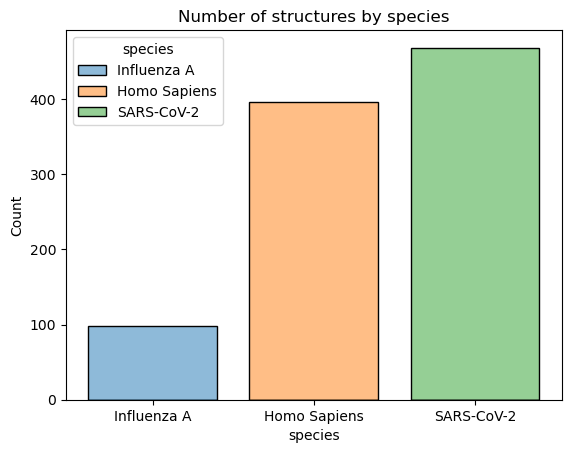

In [4]:
sns.histplot(df, x = 'species', hue = 'species', shrink = 0.8)
plt.title("Number of structures by species")
plt.show()

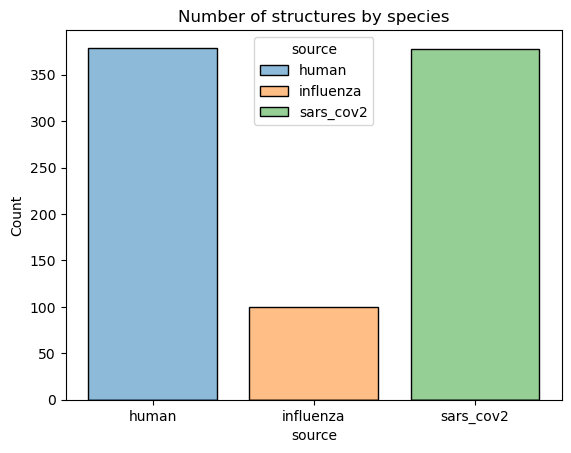

In [5]:
sns.histplot(df2, x = 'source', hue = 'source', shrink = 0.8)
plt.title("Number of structures by species")
plt.show()

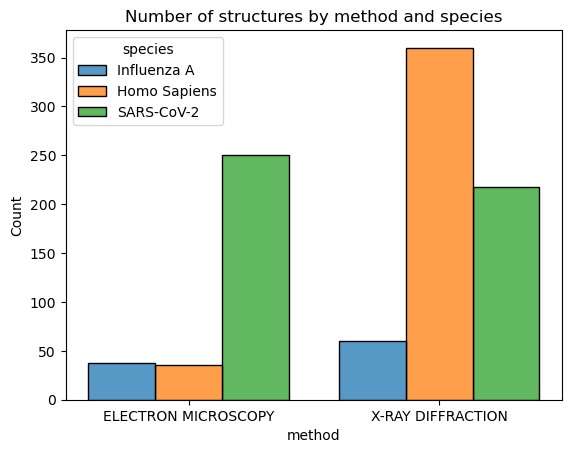

In [6]:
sns.histplot(df, x = 'method', hue = 'species', multiple = 'dodge', shrink = 0.8)
plt.title("Number of structures by method and species")
plt.show()

In [7]:
tbl = pd.crosstab(df.species, df.method)
tbl

method,ELECTRON MICROSCOPY,X-RAY DIFFRACTION
species,,
Homo Sapiens,36,360
Influenza A,38,60
SARS-CoV-2,250,218


In [8]:
tbl = pd.crosstab(df.species, df.engineered)
tbl

engineered,False,True
species,,
Homo Sapiens,12,384
Influenza A,1,97
SARS-CoV-2,4,464


In [9]:
chi2_stat, p, dof, expected = chi2_contingency(tbl.to_numpy())
p

0.04506812318539594

In [10]:
df_filtered = pd.read_csv("../generated/data cleanup/ab_ag_filtered_pdb.tsv", sep="\t")

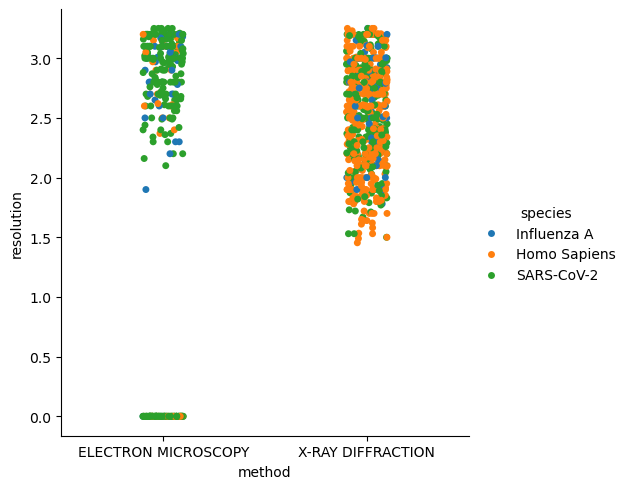

In [11]:
import seaborn as sns
sns.catplot(df_filtered,x="method", y="resolution", kind = "strip", hue="species")

In [12]:
pd.crosstab(df_filtered["species"], df_filtered["method"])

method,ELECTRON MICROSCOPY,X-RAY DIFFRACTION
species,,
Homo Sapiens,36,360
Influenza A,38,60
SARS-CoV-2,250,218


In [13]:
# 1. Filter for SARS-CoV-2 and ELECTRON MICROSCOPY
mask = (df_filtered["species"] == "SARS-CoV-2") & (df_filtered["method"] == "ELECTRON MICROSCOPY")

# 2. Get the resolution values as a list
sars_cov2_em_resolutions = df_filtered.loc[mask, "resolution"].tolist()

print(sars_cov2_em_resolutions)

[2.65, 2.37, 2.8, 3.04, 2.87, 2.84, 2.92, 3.04, 2.96, 2.93, 2.6, 3.2, 3.1, 3.1, 2.49, 3.02, 3.21, 3.16, 2.87, 3.05, 3.04, 2.78, 2.93, 3.14, 2.95, 3.0, 2.7, 3.1, 3.1, 2.6, 2.5, 2.16, 2.1, 2.61, 3.2, 2.72, 2.68, 2.8, 2.8, 2.8, 2.68, 2.56, 2.3, 3.0, 2.7, 3.2, 3.1, 2.2, 2.7, 2.75, 2.85, 2.65, 3.2, 2.34, 2.56, 2.7, 2.36, 2.91, 3.01, 2.9, 3.16, 3.09, 3.03, 3.2, 2.44, 3.07, 2.99, 3.2, 3.1, 3.1, 3.0, 3.2, 2.9, 3.2, 2.5, 3.18, 2.66, 0.0, 0.0, 0.0, 2.6, 0.0, 0.0, 0.0, 0.0, 3.08, 2.8, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.49, 3.19, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.25, 3.04, 0.0, 3.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.66, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.2, 3.22, 2.97, 3.1, 3.1, 3.0, 3.15, 2.8

<Axes: xlabel='resolution', ylabel='Count'>

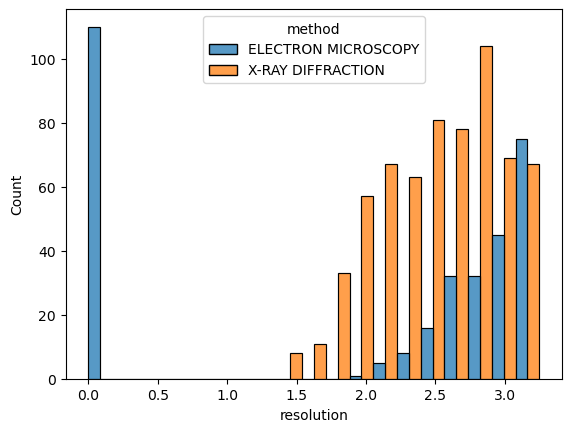

In [14]:
sns.histplot(df, x = 'resolution', hue = 'method', multiple = 'dodge')

<Axes: xlabel='method', ylabel='resolution'>

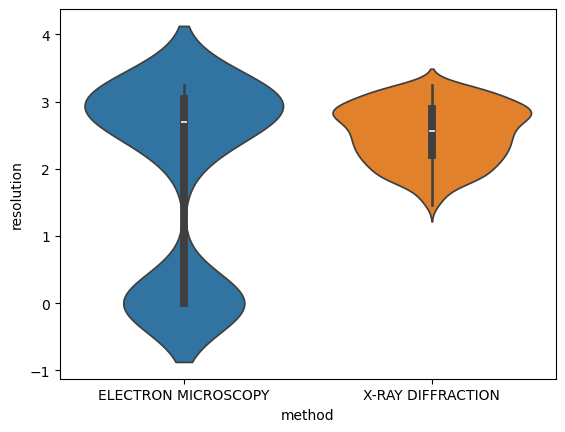

In [15]:
# here x and hue are the same. simply nicer to use color as well

sns.violinplot(x = 'method', y = 'resolution', hue = 'method', data = df)

In [16]:
df.model.value_counts()

model
0    962
Name: count, dtype: int64

In [17]:
df.engineered.value_counts()

engineered
True     945
False     17
Name: count, dtype: int64

In [18]:
df.antigen_name.value_counts()

antigen_name
spike glycoprotein                                                201
spike protein s1                                                  198
hemagglutinin                                                      48
surface glycoprotein                                               26
neuraminidase                                                      25
                                                                 ... 
spike protein s2                                                    1
9mer peptide,beta-2-microglobulin,mhc class i antigenchimera        1
sars-cov-2 rbd                                                      1
receptor tyrosine-protein kinase erbb-2/higg1 fc domainfusion       1
interleukin-22                                                      1
Name: count, Length: 242, dtype: int64